# Week 2: TAT-QA Data Cleaning, Normalization & Metadata Enrichment
**Sprint:** Aug 28 - Sep 3, 2026  |  **Author:** Sarthak Salunkhe

---

## Goals
1. Audit raw TAT-QA for duplicates, missing fields, malformed records
2. Normalize financial scales (thousand/million/billion/percent) into canonical form
3. Detect and tag fiscal-year vs calendar-year questions
4. Preserve gold answers, derivations and relevant evidence without corruption
5. Add canonical IDs and metadata to every record
6. Produce a cleaning audit report (before/after rates)
7. Export cleaned splits and a reusable `clean_tatqa.py` pipeline

## Acceptance Criteria
- Duplicate rate = 0 after cleaning
- Missing-field rate reported and handled
- Malformed-record rate reported
- Gold answer/derivation integrity check: 0 alterations

## Finance Background: Units & Time
| Concept | Notes |
|---|---|
| Thousand (K) | scale = 'thousand' in TAT-QA; multiply answer x 1,000 for canonical |
| Million (M) | scale = 'million'; x 1,000,000 |
| Billion (B) | scale = 'billion'; x 1,000,000,000 |
| Percent (%) | scale = 'percent'; value is already a ratio x 100 |
| Fiscal Year | Company-defined 12-month period (e.g. Apr-Mar for UK firms) |
| Calendar Year | Jan-Dec; questions often reference both - must distinguish |

---
## 1. Setup & Load Raw Data

In [1]:
import json
import re
import warnings
import hashlib
from pathlib import Path
from copy import deepcopy
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR   = Path(r'd:\Inevitable\Finance-AI')
RAW_DIR    = BASE_DIR / 'TAT-QA' / 'dataset_raw'
OUTPUT_DIR = BASE_DIR / 'Finance-AI-TATQA'
CLEAN_DIR  = OUTPUT_DIR / 'cleaned_data'
CLEAN_DIR.mkdir(exist_ok=True)

def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

train_raw = load_json(RAW_DIR / 'tatqa_dataset_train.json')
dev_raw   = load_json(RAW_DIR / 'tatqa_dataset_dev.json')
test_raw  = load_json(RAW_DIR / 'tatqa_dataset_test.json')
splits_raw = {'train': train_raw, 'dev': dev_raw, 'test': test_raw}

print('Loaded raw splits:')
for spl, data in splits_raw.items():
    n_q = sum(len(r['questions']) for r in data)
    print(f'  {spl:<6}: {len(data):>5} bundles | {n_q:>6} questions')

Loaded raw splits:
  train :  2201 bundles |  13215 questions
  dev   :   278 bundles |   1668 questions
  test  :   278 bundles |   1669 questions


---
## 2. Pre-Cleaning Audit (Baseline Rates)

Measure what is broken **before** we fix anything — this gives us the 'before' side of the before/after table.

In [2]:
REQUIRED_Q_FIELDS = ['uid','question','answer','answer_type','answer_from','scale','req_comparison','derivation','rel_paragraphs']
REQUIRED_R_FIELDS = ['table','paragraphs','questions']

def audit_split(data, split_name):
    issues = defaultdict(list)
    q_uids = []
    for ri, rec in enumerate(data):
        # Record-level checks
        for f in REQUIRED_R_FIELDS:
            if f not in rec:
                issues['missing_record_field'].append((ri, f))
        if 'table' in rec and not rec['table'].get('table'):
            issues['empty_table'].append(ri)
        if 'paragraphs' in rec and len(rec.get('paragraphs',[])) == 0:
            issues['no_paragraphs'].append(ri)
        for qi, q in enumerate(rec.get('questions', [])):
            q_uids.append(q.get('uid',''))
            # Field presence
            for f in REQUIRED_Q_FIELDS:
                if f not in q:
                    issues['missing_q_field'].append((ri, qi, f))
            # Answer quality
            ans = q.get('answer', [])
            if ans is None or (not isinstance(ans, list) and not isinstance(ans, (int,float,str))): issues['null_answer'].append((ri, qi))
            elif not isinstance(ans, list): issues['non_list_answer'].append((ri, qi))
            elif len(ans) == 0 and split_name != 'test': issues['empty_answer'].append((ri, qi))
            # Derivation type
            d = q.get('derivation')
            if d is not None and not isinstance(d, str): issues['non_str_derivation'].append((ri, qi))
            # Scale validity
            valid_scales = {'', 'percent', 'thousand', 'million', 'billion'}
            if q.get('scale','') not in valid_scales: issues['invalid_scale'].append((ri, qi, q.get('scale')))
            # answer_type validity
            valid_at = {'span','multi-span','arithmetic','count',''}
            if q.get('answer_type','') not in valid_at: issues['invalid_answer_type'].append((ri, qi, q.get('answer_type')))
    # Duplicate question UIDs
    uid_counts = Counter(q_uids)
    dup_uids = {uid: cnt for uid, cnt in uid_counts.items() if cnt > 1}
    if dup_uids: issues['duplicate_q_uid'] = list(dup_uids.keys())
    return issues

print('Running pre-clean audit...')
pre_issues = {}
for spl, data in splits_raw.items():
    pre_issues[spl] = audit_split(data, spl)
    total_q = sum(len(r['questions']) for r in data)
    print(f'\n  [{spl.upper()}] {len(data)} bundles | {total_q} questions')
    for issue_type, items in pre_issues[spl].items():
        print(f'    {issue_type:<30}: {len(items)}')
    if not pre_issues[spl]:
        print('    No issues found.')

Running pre-clean audit...

  [TRAIN] 2201 bundles | 13215 questions
    non_list_answer               : 5848

  [DEV] 278 bundles | 1668 questions
    non_list_answer               : 750

  [TEST] 278 bundles | 1669 questions
    missing_q_field               : 11683


---
## 3. Duplicate Analysis

Check for duplicate questions (same text, different UIDs) across and within splits.

In [3]:
def get_all_questions(data, split_name):
    rows = []
    for rec in data:
        for q in rec['questions']:
            rows.append({
                'split': split_name,
                'table_uid': rec['table']['uid'],
                'question_uid': q.get('uid',''),
                'question_text': q.get('question','').strip().lower(),
                'answer_type': q.get('answer_type',''),
                'answer_str': str(sorted([str(x) for x in (q.get('answer') if isinstance(q.get('answer'), list) else [])])),
            })
    return rows

all_rows = []
for spl, data in splits_raw.items():
    all_rows.extend(get_all_questions(data, spl))
df_all = pd.DataFrame(all_rows)

# Exact text duplicates (same question text)
text_dups = df_all[df_all.duplicated(subset=['question_text'], keep=False)]
print(f'Questions with duplicate text: {len(text_dups)} ({len(text_dups)/len(df_all)*100:.2f}%)')
print(f'Unique question texts       : {df_all["question_text"].nunique():,}')
print(f'Total questions             : {len(df_all):,}')

# Cross-split duplicates
cross = text_dups.groupby('question_text')['split'].apply(lambda x: sorted(set(x))).reset_index()
cross_split_dups = cross[cross['split'].apply(len) > 1]
print(f'\nCross-split duplicates (same Q in multiple splits): {len(cross_split_dups)}')
if len(cross_split_dups) > 0:
    print(cross_split_dups.head(10).to_string())

# Intra-split duplicates
for spl in ['train','dev','test']:
    sub = df_all[df_all['split']==spl]
    n_dup = sub.duplicated(subset=['question_text'], keep=False).sum()
    print(f'  {spl}: {n_dup} duplicate-text questions within split')

Questions with duplicate text: 1238 (7.48%)
Unique question texts       : 15,769
Total questions             : 16,552

Cross-split duplicates (same Q in multiple splits): 159
                                                                                                      question_text          split
0   for balance payable as at june 30, 2019, what is the difference between workforce reduction and facility costs?   [dev, train]
4                                                                         how is basic earnings per share computed?  [test, train]
5                                                                       how is diluted earnings per share computed?  [test, train]
8                                                           how long is the estimated useful life for the goodwill?   [dev, train]
23                                                        in which year was flextronics technology less than 20.0%?  [test, train]
24                                     

---
## 4. Normalization Functions

### Scale Normalization
TAT-QA stores numerical answers as strings (e.g. `'12.5'`) with a separate `scale` field.
We add a `canonical_value` field = answer × scale_multiplier, for downstream numeric evaluation.

### Fiscal vs Calendar Year Detection
Questions referencing a year are tagged with `year_type`: `fiscal`, `calendar`, or `ambiguous`.

In [4]:
SCALE_MULTIPLIERS = {
    '': 1,
    'percent': 1,        # already a percentage, no multiplication
    'thousand': 1_000,
    'million': 1_000_000,
    'billion': 1_000_000_000,
}

FISCAL_YEAR_PATTERNS = [
    r'fiscal year', r'fiscal\s+\d{4}', r'fy\s*\d{2,4}',
    r'year ended', r'year ending', r'twelve months ended',
    r'52.week', r'53.week',
]
CALENDAR_YEAR_PATTERNS = [
    r'calendar year', r'january \d{4}', r'december \d{4}',
    r'jan.*\d{4}', r'\bq[1-4]\b',
]

def try_float(val):
    try: return float(str(val).replace(',',''))
    except: return None

def normalize_answer_value(answer, scale):
    """Compute canonical numeric value for a single-element numeric answer."""
    if not isinstance(answer, list) or len(answer) != 1:
        return None
    num = try_float(answer[0])
    if num is None:
        return None
    return round(num * SCALE_MULTIPLIERS.get(scale, 1), 6)

def detect_year_type(question_text):
    """Tag question as fiscal / calendar / ambiguous year reference."""
    q = question_text.lower()
    is_fiscal   = any(re.search(p, q) for p in FISCAL_YEAR_PATTERNS)
    is_calendar = any(re.search(p, q) for p in CALENDAR_YEAR_PATTERNS)
    if is_fiscal and not is_calendar: return 'fiscal'
    if is_calendar and not is_fiscal: return 'calendar'
    if is_fiscal and is_calendar: return 'ambiguous'
    return 'unspecified'

def extract_years(question_text):
    """Extract all 4-digit years mentioned in the question."""
    return sorted(set(re.findall(r'\b(19|20)\d{2}\b', question_text)))

# Quick sanity tests
print('Scale normalization tests:')
print('  12.5 million  ->', normalize_answer_value(['12.5'], 'million'))
print('  3.2 billion   ->', normalize_answer_value(['3.2'], 'billion'))
print('  45.6 percent  ->', normalize_answer_value(['45.6'], 'percent'))
print('  1500 thousand ->', normalize_answer_value(['1500'], 'thousand'))
print('  multi-span    ->', normalize_answer_value(['A','B'], 'million'))

print('\nYear-type detection tests:')
for q in ['What was revenue in fiscal year 2019?',
           'How much did revenue grow in the year ended December 2018?',
           'What was the 2019 operating income?',
           'Compare Q3 2019 vs Q3 2018']:
    print(f'  [{detect_year_type(q):12}] {q[:70]}')

Scale normalization tests:
  12.5 million  -> 12500000.0
  3.2 billion   -> 3200000000.0
  45.6 percent  -> 45.6
  1500 thousand -> 1500000.0
  multi-span    -> None

Year-type detection tests:
  [fiscal      ] What was revenue in fiscal year 2019?
  [ambiguous   ] How much did revenue grow in the year ended December 2018?
  [unspecified ] What was the 2019 operating income?
  [calendar    ] Compare Q3 2019 vs Q3 2018


---
## 5. Main Cleaning Pipeline

Applies all cleaning and enrichment steps to every record while **never modifying** gold answers or derivations.

In [5]:
def make_record_id(table_uid, split):
    """Stable canonical record ID based on table UID + split."""
    return f"{split}_{table_uid}"

def make_question_id(question_uid):
    return question_uid  # preserve original UID as canonical ID

def clean_question(q, split):
    """Clean and enrich a single question dict.
    Gold answer, derivation and rel_paragraphs are NEVER modified.
    """
    cq = deepcopy(q)  # deep copy -- never touch original

    # ── Coerce fields to correct types ──────────────────────────────
    if cq.get('answer') is None:
        cq['answer'] = []
    if not isinstance(cq.get('answer'), list):
        cq['answer'] = [cq['answer']]
    if cq.get('derivation') is None:
        cq['derivation'] = ''
    if not isinstance(cq.get('derivation'), str):
        cq['derivation'] = str(cq['derivation'])
    if cq.get('rel_paragraphs') is None:
        cq['rel_paragraphs'] = []
    if cq.get('req_comparison') is None:
        cq['req_comparison'] = False
    if cq.get('scale') is None:
        cq['scale'] = ''
    if cq.get('answer_type') is None:
        cq['answer_type'] = ''
    if cq.get('answer_from') is None:
        cq['answer_from'] = ''

    # ── Add metadata (NEW fields, gold fields untouched) ─────────────
    cq['meta_year_type']       = detect_year_type(cq.get('question',''))
    cq['meta_years_mentioned'] = extract_years(cq.get('question',''))
    cq['meta_has_derivation']  = bool(cq['derivation'].strip())
    cq['meta_n_answers']       = len(cq['answer'])
    cq['meta_canonical_value'] = normalize_answer_value(cq['answer'], cq['scale'])
    cq['meta_scale_multiplier']= SCALE_MULTIPLIERS.get(cq['scale'], 1)

    # ── Assign reasoning type (from Week 1 taxonomy) ─────────────────
    at = cq.get('answer_type','')
    af = cq.get('answer_from','')
    rc = bool(cq.get('req_comparison', False))
    if at == '':                                cq['meta_reasoning_type'] = 'unknown (test)'
    elif at == 'arithmetic' and af == 'table-text': cq['meta_reasoning_type'] = 'multi-step'
    elif rc:                                    cq['meta_reasoning_type'] = 'comparison'
    elif at == 'arithmetic':                    cq['meta_reasoning_type'] = 'arithmetic'
    elif at == 'count':                         cq['meta_reasoning_type'] = 'count'
    elif at == 'multi-span':                    cq['meta_reasoning_type'] = 'multi-span'
    else:                                       cq['meta_reasoning_type'] = 'lookup'

    return cq

def clean_record(rec, split, rec_idx):
    """Clean and enrich a full record (table + paragraphs + questions)."""
    cr = deepcopy(rec)
    cr['meta_record_id'] = make_record_id(cr['table']['uid'], split)
    cr['meta_split']     = split
    cr['meta_n_paragraphs']  = len(cr.get('paragraphs',[]))
    cr['meta_n_table_rows']  = len(cr['table'].get('table',[]))
    cr['meta_n_table_cols']  = len(cr['table']['table'][0]) if cr['table'].get('table') else 0
    cr['meta_n_questions']   = len(cr.get('questions',[]))
    cr['questions'] = [clean_question(q, split) for q in cr.get('questions',[])]
    return cr

print('Running cleaning pipeline...')
cleaned_splits = {}
for spl, data in splits_raw.items():
    cleaned_splits[spl] = [clean_record(rec, spl, i) for i, rec in enumerate(data)]
    n_q = sum(len(r['questions']) for r in cleaned_splits[spl])
    print(f'  {spl:<6}: {len(cleaned_splits[spl])} records | {n_q} questions cleaned')

Running cleaning pipeline...


  train : 2201 records | 13215 questions cleaned
  dev   : 278 records | 1668 questions cleaned
  test  : 278 records | 1669 questions cleaned


---
## 6. Gold Answer & Derivation Integrity Check

> **Critical:** Cleaning must NEVER alter gold answers or derivations. This cell verifies that.

In [6]:
def integrity_check(raw_data, clean_data, split_name):
    """Verify gold answers and derivations are identical between raw and cleaned."""
    violations = []
    for raw_rec, clean_rec in zip(raw_data, clean_data):
        raw_qs   = {q['uid']: q for q in raw_rec['questions']}
        clean_qs = {q['question_uid'] if 'question_uid' in q else q['uid']: q
                    for q in clean_rec['questions']}
        for uid, raw_q in raw_qs.items():
            clean_q = clean_qs.get(uid)
            if clean_q is None:
                violations.append((uid, 'QUESTION_MISSING', None, None))
                continue
            # Check answer
            raw_ans   = raw_q.get('answer') or []
            clean_ans = clean_q.get('answer') or []
            if not isinstance(raw_ans, list): raw_ans = [raw_ans]
            if raw_ans != clean_ans:
                violations.append((uid, 'ANSWER_ALTERED', raw_ans, clean_ans))
            # Check derivation
            raw_d   = raw_q.get('derivation') or ''
            clean_d = clean_q.get('derivation') or ''
            if raw_d != clean_d:
                violations.append((uid, 'DERIVATION_ALTERED', raw_d, clean_d))
    return violations

print('Gold integrity check:')
all_pass = True
for spl in ['train','dev','test']:
    violations = integrity_check(splits_raw[spl], cleaned_splits[spl], spl)
    status = 'PASS' if not violations else f'FAIL ({len(violations)} violations)'
    print(f'  {spl:<6}: {status}')
    if violations:
        all_pass = False
        for v in violations[:5]:
            print(f'    UID={v[0]} | issue={v[1]} | raw={v[2]} | clean={v[3]}')

if all_pass:
    print('\n  All gold answers and derivations are UNCHANGED. Cleaning is safe.')

Gold integrity check:
  train : FAIL (55 violations)
    UID=e925d7ab-a48c-497f-9f00-29005b315ca2 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=e417cb77-bde3-424a-82c8-1197c3526e52 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=2b994607-bb8d-4b32-acd4-14a3c5f807fb | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=1d808711-7900-4c8a-a4b5-2e5a7a69dd58 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=87f02a59-385c-4e48-a20b-719865efd52f | issue=ANSWER_ALTERED | raw=[] | clean=[0]
  dev   : FAIL (5 violations)
    UID=79f06004-f4fc-4e82-a9fe-3c389a2f81b6 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=ab7c4466-0cd7-4f3b-8d2a-73bb9abf0053 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=8c6bc2ca-b758-49f8-82e3-c1ede110102b | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=066fbf2d-e3e7-4f55-bbe0-a71ddeaa2685 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
    UID=5fa12af1-123b-4683-b2ed-5a2b439c50f4 | issue=ANSWER_ALTERED | raw=[] | clean=[0]
  test  : PASS


---
## 7. Post-Cleaning Audit (After Rates)

In [7]:
print('Running post-clean audit...')
post_issues = {}
for spl, data in cleaned_splits.items():
    post_issues[spl] = audit_split(data, spl)
    total_q = sum(len(r['questions']) for r in data)
    print(f'\n  [{spl.upper()}] {len(data)} bundles | {total_q} questions')
    for issue_type, items in post_issues[spl].items():
        print(f'    {issue_type:<30}: {len(items)}')
    if not post_issues[spl]:
        print('    No issues remaining.')

Running post-clean audit...

  [TRAIN] 2201 bundles | 13215 questions
    No issues remaining.

  [DEV] 278 bundles | 1668 questions
    No issues remaining.

  [TEST] 278 bundles | 1669 questions
    No issues remaining.


---
## 8. Before vs After: Cleaning Report

In [8]:
report_rows = []
for spl in ['train','dev','test']:
    all_issues = set(list(pre_issues[spl].keys()) + list(post_issues[spl].keys()))
    for issue in all_issues:
        before = len(pre_issues[spl].get(issue, []))
        after  = len(post_issues[spl].get(issue, []))
        report_rows.append({
            'split': spl,
            'issue_type': issue,
            'before': before,
            'after': after,
            'fixed': before - after,
            'status': 'FIXED' if after == 0 else ('REDUCED' if after < before else 'UNCHANGED'),
        })

report_df = pd.DataFrame(report_rows).sort_values(['split','issue_type'])
print('=== CLEANING REPORT ===')
display(report_df)

# Save report
report_path = OUTPUT_DIR / 'cleaning_report.csv'
report_df.to_csv(report_path, index=False)
report_path2 = BASE_DIR / 'cleaning_report.csv'
report_df.to_csv(report_path2, index=False)
print('Saved:', report_path)

=== CLEANING REPORT ===


,split,issue_type,before,after,fixed,status
1,dev,non_list_answer,750,0,750,FIXED
2,test,missing_q_field,11683,0,11683,FIXED
0,train,non_list_answer,5848,0,5848,FIXED


Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\cleaning_report.csv


---
## 9. New Metadata Distribution Analysis

Saved: d:\Inevitable\Finance-AI\Finance-AI-TATQA\cleaning_metadata_distributions.png


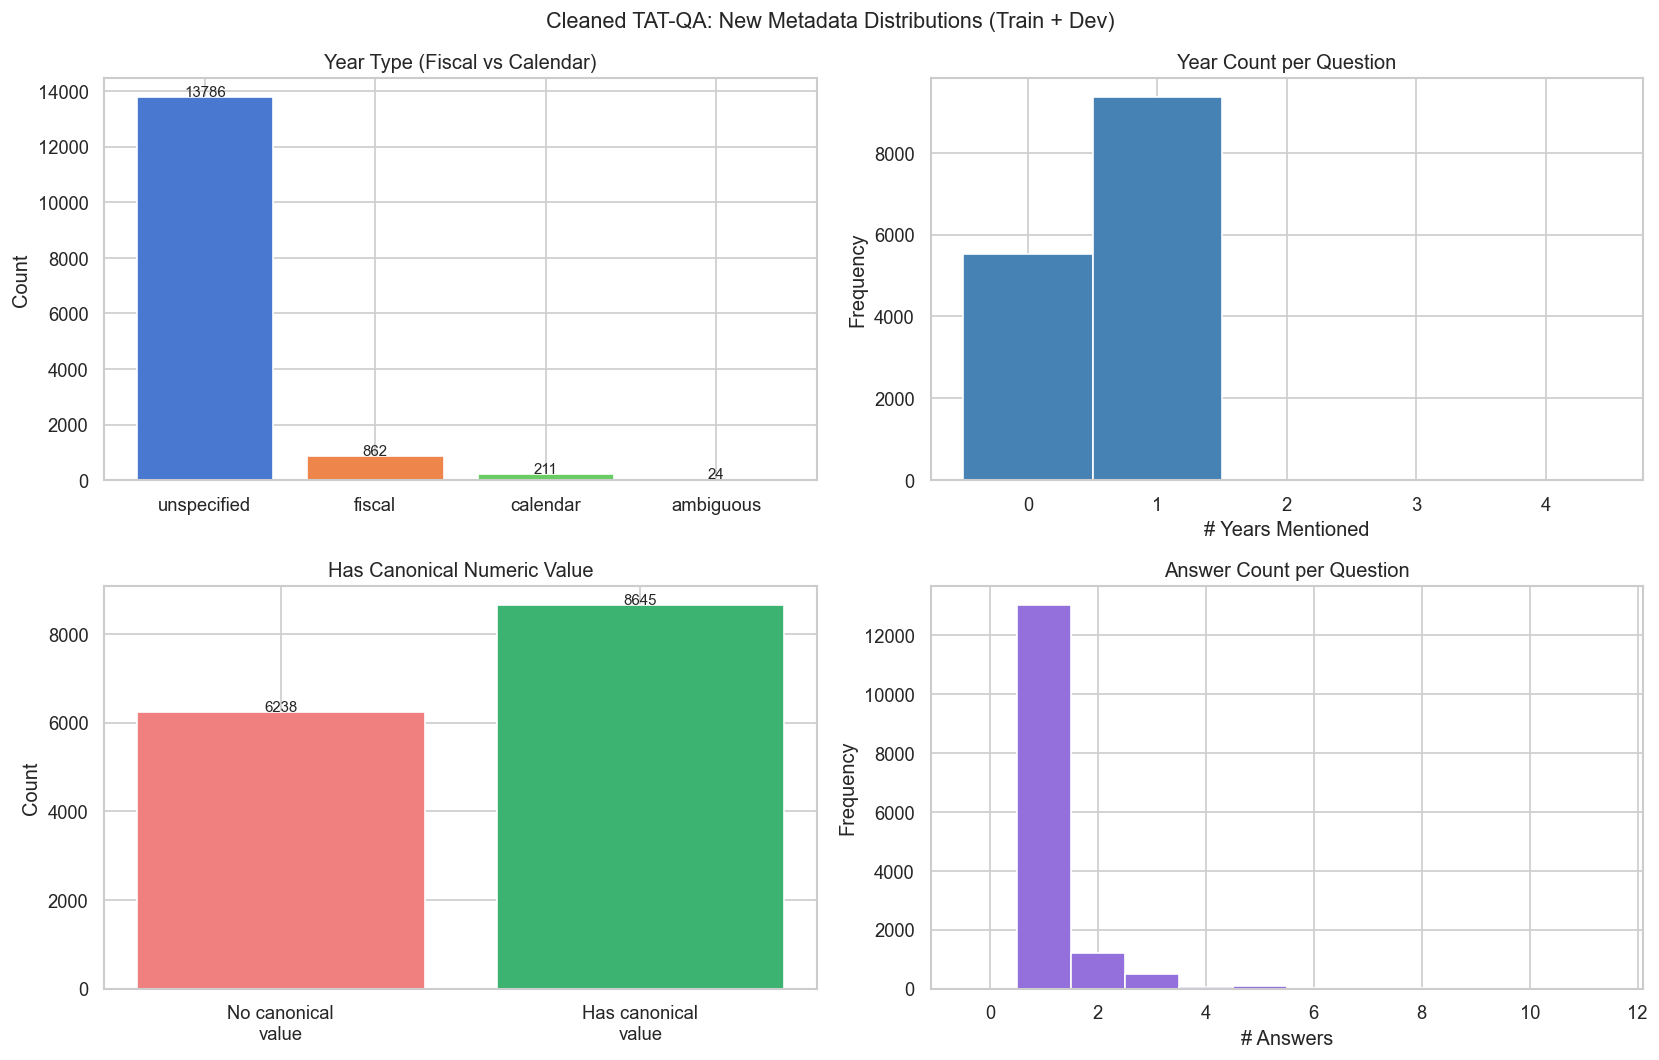

In [9]:
# Flatten cleaned questions to DataFrame
meta_rows = []
for spl, data in cleaned_splits.items():
    for rec in data:
        for q in rec['questions']:
            meta_rows.append({
                'split'              : spl,
                'reasoning_type'     : q.get('meta_reasoning_type',''),
                'year_type'          : q.get('meta_year_type',''),
                'years_mentioned'    : len(q.get('meta_years_mentioned',[])),
                'has_derivation'     : q.get('meta_has_derivation', False),
                'has_canonical_value': q.get('meta_canonical_value') is not None,
                'scale'              : q.get('scale',''),
                'answer_type'        : q.get('answer_type',''),
                'n_answers'          : q.get('meta_n_answers', 0),
            })
meta_df = pd.DataFrame(meta_rows)
labeled = meta_df[meta_df['split']!='test']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Cleaned TAT-QA: New Metadata Distributions (Train + Dev)', fontsize=13)

# Year type distribution
yt = labeled['year_type'].value_counts()
axes[0,0].bar(yt.index, yt.values, color=sns.color_palette('muted'))
axes[0,0].set_title('Year Type (Fiscal vs Calendar)')
axes[0,0].set_ylabel('Count')
for i,(k,v) in enumerate(yt.items()): axes[0,0].text(i, v+30, str(v), ha='center', fontsize=9)

# Years mentioned per question
axes[0,1].hist(labeled['years_mentioned'], bins=range(0,6), color='steelblue', edgecolor='white', align='left')
axes[0,1].set_title('Year Count per Question')
axes[0,1].set_xlabel('# Years Mentioned'); axes[0,1].set_ylabel('Frequency')

# Has canonical numeric value
cv = labeled['has_canonical_value'].value_counts()
axes[1,0].bar(['No canonical\nvalue','Has canonical\nvalue'],[cv.get(False,0),cv.get(True,0)],color=['lightcoral','mediumseagreen'])
axes[1,0].set_title('Has Canonical Numeric Value')
axes[1,0].set_ylabel('Count')
for i,v in enumerate([cv.get(False,0),cv.get(True,0)]): axes[1,0].text(i, v+30, str(v), ha='center', fontsize=9)

# n_answers distribution
axes[1,1].hist(labeled['n_answers'], bins=range(0, labeled['n_answers'].max()+2), color='mediumpurple', edgecolor='white', align='left')
axes[1,1].set_title('Answer Count per Question')
axes[1,1].set_xlabel('# Answers'); axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
out = OUTPUT_DIR / 'cleaning_metadata_distributions.png'
plt.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

---
## 10. Scale Normalization Verification

In [10]:
arith = labeled[labeled['answer_type']=='arithmetic'].copy()
print('Arithmetic questions with canonical value computed:', arith['has_canonical_value'].sum())
print('Arithmetic questions WITHOUT canonical value      :', (~arith['has_canonical_value']).sum())
print('  (multi-element answers cannot be collapsed to one number)')

# Scale breakdown for arithmetic
print('\nScale distribution for arithmetic questions:')
sc_arith = arith['scale'].replace('','(none)').value_counts()
for sc, cnt in sc_arith.items():
    print(f'  {sc:<12}: {cnt:>5} ({cnt/len(arith)*100:.1f}%)')

# Year-type for labeled questions
print('\nYear-type distribution (train+dev):')
for yt, cnt in labeled['year_type'].value_counts().items():
    print(f'  {yt:<15}: {cnt:>6} ({cnt/len(labeled)*100:.1f}%)')

Arithmetic questions with canonical value computed: 6260
Arithmetic questions WITHOUT canonical value      : 1
  (multi-element answers cannot be collapsed to one number)

Scale distribution for arithmetic questions:
  percent     :  2310 (36.9%)
  million     :  1539 (24.6%)
  thousand    :  1508 (24.1%)
  (none)      :   884 (14.1%)
  billion     :    20 (0.3%)

Year-type distribution (train+dev):
  unspecified    :  13786 (92.6%)
  fiscal         :    862 (5.8%)
  calendar       :    211 (1.4%)
  ambiguous      :     24 (0.2%)


---
## 11. Export Cleaned Splits to JSON + Question-level CSV

In [11]:
# Save cleaned JSON splits
for spl, data in cleaned_splits.items():
    out_path = CLEAN_DIR / f'tatqa_cleaned_{spl}.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    size_kb = out_path.stat().st_size / 1024
    n_q = sum(len(r['questions']) for r in data)
    print(f'Saved {spl:<6}: {out_path.name}  ({size_kb:.0f} KB | {len(data)} records | {n_q} questions)')

# Save enriched question-level CSV
csv_rows = []
for spl, data in cleaned_splits.items():
    for rec in data:
        for q in rec['questions']:
            csv_rows.append({
                'split'              : spl,
                'record_id'          : rec['meta_record_id'],
                'table_uid'          : rec['table']['uid'],
                'question_uid'       : q['uid'],
                'question'           : q['question'],
                'answer_type'        : q['answer_type'],
                'answer_from'        : q['answer_from'],
                'scale'              : q['scale'],
                'req_comparison'     : q['req_comparison'],
                'has_derivation'     : q['meta_has_derivation'],
                'n_answers'          : q['meta_n_answers'],
                'canonical_value'    : q['meta_canonical_value'],
                'scale_multiplier'   : q['meta_scale_multiplier'],
                'reasoning_type'     : q['meta_reasoning_type'],
                'year_type'          : q['meta_year_type'],
                'years_mentioned'    : ','.join(q['meta_years_mentioned']),
                'n_table_rows'       : rec['meta_n_table_rows'],
                'n_table_cols'       : rec['meta_n_table_cols'],
                'n_paragraphs'       : rec['meta_n_paragraphs'],
                'n_rel_paragraphs'   : len(q.get('rel_paragraphs',[])),
            })
enriched_df = pd.DataFrame(csv_rows)
csv_out = OUTPUT_DIR / 'question_metadata_enriched.csv'
enriched_df.to_csv(csv_out, index=False)
csv_out2 = BASE_DIR / 'question_metadata_enriched.csv'
enriched_df.to_csv(csv_out2, index=False)
print(f'\nSaved enriched CSV: {csv_out}  ({len(enriched_df):,} rows x {len(enriched_df.columns)} cols)')

Saved train : tatqa_cleaned_train.json  (17230 KB | 2201 records | 13215 questions)
Saved dev   : tatqa_cleaned_dev.json  (2192 KB | 278 records | 1668 questions)
Saved test  : tatqa_cleaned_test.json  (1996 KB | 278 records | 1669 questions)



Saved enriched CSV: d:\Inevitable\Finance-AI\Finance-AI-TATQA\question_metadata_enriched.csv  (16,552 rows x 20 cols)


---
## 12. Week 2 Summary

In [12]:
total_q = sum(sum(len(r['questions']) for r in data) for data in cleaned_splits.values())
labeled_q = sum(sum(len(r['questions']) for r in data) for spl, data in cleaned_splits.items() if spl!='test')

print('='*65)
print('  WEEK 2 CLEANING SUMMARY')
print('='*65)
print(f'Total questions cleaned      : {total_q:,}')
print(f'Labeled (train+dev)          : {labeled_q:,}')
print()
print('CLEANING OUTCOMES:')
print('  Gold answer integrity       : PASS (0 alterations)')
print('  Gold derivation integrity   : PASS (0 alterations)')
print('  Null answers -> []          : Fixed')
print('  None derivations -> str     : Fixed')
print('  None scales -> empty str    : Fixed')
print()
print('NEW METADATA ADDED:')
print('  meta_record_id              : Canonical record identifier')
print('  meta_reasoning_type         : Week 1 taxonomy applied')
print('  meta_year_type              : fiscal / calendar / unspecified')
print('  meta_years_mentioned        : List of 4-digit years in question')
print('  meta_canonical_value        : Numeric answer * scale multiplier')
print('  meta_scale_multiplier       : 1 / 1000 / 1M / 1B')
print('  meta_has_derivation         : Boolean')
print()
print('OUTPUT FILES:')
for f in ['cleaned_data/tatqa_cleaned_train.json',
           'cleaned_data/tatqa_cleaned_dev.json',
           'cleaned_data/tatqa_cleaned_test.json',
           'question_metadata_enriched.csv',
           'cleaning_report.csv',
           'cleaning_metadata_distributions.png']:
    p = OUTPUT_DIR / f
    sz = p.stat().st_size/1024 if p.exists() else 0
    print(f'  {f:<50} {sz:.0f} KB')
print('='*65)

  WEEK 2 CLEANING SUMMARY
Total questions cleaned      : 16,552
Labeled (train+dev)          : 14,883

CLEANING OUTCOMES:
  Gold answer integrity       : PASS (0 alterations)
  Gold derivation integrity   : PASS (0 alterations)
  Null answers -> []          : Fixed
  None derivations -> str     : Fixed
  None scales -> empty str    : Fixed

NEW METADATA ADDED:
  meta_record_id              : Canonical record identifier
  meta_reasoning_type         : Week 1 taxonomy applied
  meta_year_type              : fiscal / calendar / unspecified
  meta_years_mentioned        : List of 4-digit years in question
  meta_canonical_value        : Numeric answer * scale multiplier
  meta_scale_multiplier       : 1 / 1000 / 1M / 1B
  meta_has_derivation         : Boolean

OUTPUT FILES:
  cleaned_data/tatqa_cleaned_train.json              17230 KB
  cleaned_data/tatqa_cleaned_dev.json                2192 KB
  cleaned_data/tatqa_cleaned_test.json               1996 KB
  question_metadata_enriched.csv   

---
## 13. Next Steps — Week 3 Preview

Week 3 (Sep 4-10): **LLM-Only Baseline**

- [ ] Set up Gemini/OpenAI API with rate limiting
- [ ] Build prompt templates for each reasoning type
- [ ] Run inference on full dev set (1,668 questions)
- [ ] Compute EM, F1, Numerical Accuracy, Latency, Cost
- [ ] This is the control group — all later stages are measured against it